# Classification

In [1]:
from pathlib import Path
import json

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours

In [2]:
# PATHS

DATASET_DIR = Path("symbols_dataset")
LABELS_PATH = DATASET_DIR / "labels.json"

In [3]:
# LOAD LABELS
with open(LABELS_PATH, "r") as f:
    labels_dict = json.load(f)

print(f"Loaded {len(labels_dict)} labels")

Loaded 1090 labels


In [4]:
# LOAD SYMBOL IMAGES
images = []
labels = []
filenames = []

for filename, label in labels_dict.items():

    img_path = DATASET_DIR / filename

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Could not load:", filename)
        continue

    # ensure binary
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    images.append(binary)
    labels.append(label)
    filenames.append(filename)

images = np.array(images)

print("Images shape:", images.shape)

Images shape: (1090, 150, 150)


## Contour extraction

Ça va extraire tous les contours, intérieurs et extérieurs mais
* main external contour seulement sera utilisé pour Fourier
* les autres sont classifiés comme intérieur ou extérieur et seront utiles pour différencier +2 et 2 par ex, etc

In [16]:
def find_all_contours(images: np.ndarray):
    """
    Extract structured contours (external + internal) per image.
    """

    contours_list = []

    for img in images:

        img = img.astype(np.uint8)

        contours, hierarchy = cv2.findContours(
            img,
            cv2.RETR_TREE,   # IMPORTANT: keeps internal contours
            cv2.CHAIN_APPROX_NONE
        )

        if hierarchy is None:
            contours_list.append([])
            continue

        hierarchy = hierarchy[0]  # shape (N, 4)

        image_contours = []

        for i, c in enumerate(contours):

            coords = c[:, 0, :]  # (K,2)

            # normalize start point
            start_idx = np.argmin(coords[:, 0] + coords[:, 1])
            coords = np.roll(coords, -start_idx, axis=0)

            parent = hierarchy[i][3]  # -1 if external, else internal

            image_contours.append({
                "contour": coords,
                "area": cv2.contourArea(c),
                "length": len(coords),
                "is_internal": parent != -1
            })

        # sort by area (main shape first, but KEEP structure info)
        image_contours = sorted(
            image_contours,
            key=lambda x: x["area"],
            reverse=True
        )

        contours_list.append(image_contours)

    return contours_list

In [17]:
# EXTRACT CONTOURS

contours = find_all_contours(images)

print("Contours extracted:", len(contours))

Contours extracted: 1090


In [21]:
COLORS = [
    "red",
    "cyan",
    "yellow",
    "green",
    "magenta",
]

In [22]:
def show_contours(images, contours, labels, n=12):

    rows = min(n, len(images))

    fig, axes = plt.subplots(rows, 2, figsize=(8, 4 * rows))

    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(rows):

        img = images[i]
        label = labels[i]

        # LEFT
        axes[i, 0].imshow(img, cmap="gray")
        axes[i, 0].set_title(f"Label: {label}")
        axes[i, 0].axis("off")

        # RIGHT
        axes[i, 1].imshow(img, cmap="gray")

        if len(contours[i]) > 0:

            for j, c in enumerate(contours[i]):

                contour = c["contour"]   # MUST be here

                color = COLORS[j % len(COLORS)]

                axes[i, 1].plot(
                    contour[:, 0],
                    contour[:, 1],
                    color=color,
                    linewidth=1
                )

        axes[i, 1].set_title("Extracted contours")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

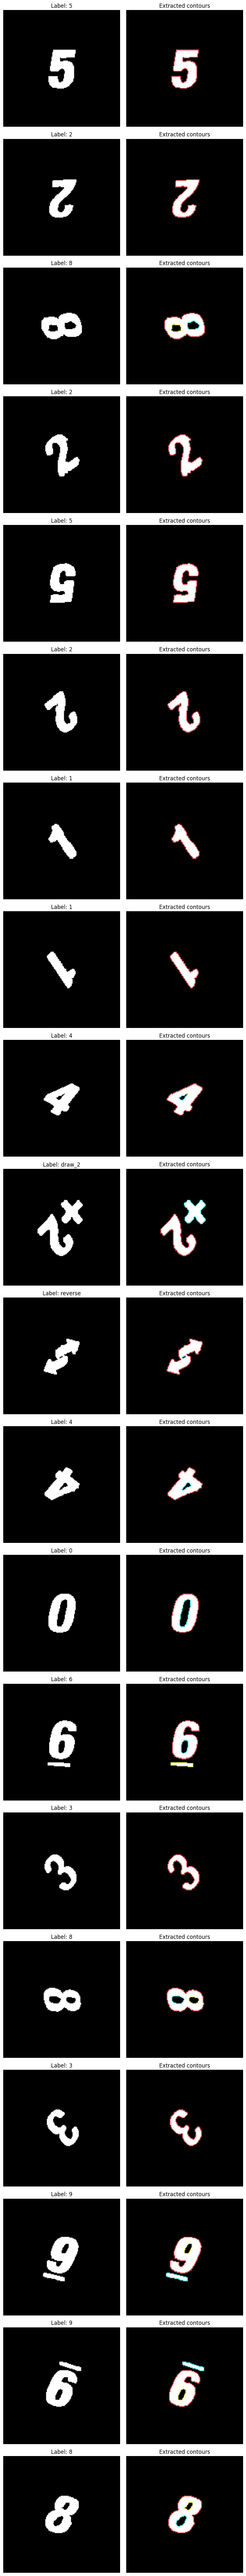

In [23]:
# DISPLAY RESULTS

show_contours(images, contours, labels, n=20)

## Fourier descriptors

In [26]:
def linear_interpolation(contour: np.ndarray, n_samples: int = 64):
    """
    Resample a single contour using arc-length interpolation.
    """

    if len(contour) < 2:
        return np.zeros((n_samples, 2))

    # compute cumulative arc length
    diff = np.diff(contour, axis=0)
    dist = np.sqrt((diff ** 2).sum(axis=1))
    t = np.insert(np.cumsum(dist), 0, 0)

    if t[-1] == 0:
        return np.repeat(contour[:1], n_samples, axis=0)

    t_new = np.linspace(0, t[-1], n_samples)

    x = np.interp(t_new, t, contour[:, 0])
    y = np.interp(t_new, t, contour[:, 1])

    return np.stack([x, y], axis=1)

In [31]:
def compute_fourier_descriptor(contours, n_coeffs=20):
    """
    Fourier descriptors for main contours only.
    """

    N = len(contours)
    descriptors = np.zeros((N, n_coeffs), dtype=np.complex128)

    for i in range(N):

        contour = contours[i]

        if len(contour) == 0:
            continue

        # 🔥 IMPORTANT: resample FIRST
        contour = linear_interpolation(contour, n_samples=64)

        z = contour[:, 0] + 1j * contour[:, 1]

        fft = np.fft.fft(z)

        # keep low-frequency components
        desc = fft[:n_coeffs]

        # padding safety
        if len(desc) < n_coeffs:
            desc = np.pad(desc, (0, n_coeffs - len(desc)))

        descriptors[i] = desc

    return descriptors

In [28]:
def apply_rotation(img):
    img = img.astype(np.uint8)
    h, w = img.shape

    angle = np.random.uniform(-180, 180)
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_NEAREST,   # important for binary masks
        borderValue=0
    )

    return rotated

In [29]:
def translation_invariant(features):
    """
    Remove translation effect from Fourier descriptors.
    """

    features_inv = features.copy()

    # DC component = centroid / global shift
    features_inv[:, 0] = 0

    return features_inv